# 04_Model_Interpretability_with_SHAP_and_LIME

### 💾 Block 1: Model Dictionary Initialization & Asset Loading
In this section, we load our dictionary of trained production models (`best_model_24h.pkl`, `best_model_48h.pkl`, and `best_model_72h.pkl`) from the disk storage. This centralized model dictionary allows us to map the correct champion model to its respective multi-horizon forecasting pipeline (24-hour, 48-hour, and 72-hour) for global and local interpretability.

In [ ]:
import joblib

# Ensure the filenames match exactly what you uploaded
champions = {
    "24h": joblib.load("best_model_24h (1).pkl"),
    "48h": joblib.load("best_model_48h (1).pkl"),
    "72h": joblib.load("best_model_72h.pkl")
}

print("Champions dictionary loaded successfully.")

Champions dictionary loaded successfully.


### 📊 Block 2: Global Feature Importance Across Forecasting Horizons (SHAP)
This block runs global SHAP (SHapley Additive exPlanations) analysis for our models across different forecasting horizons. By computing the SHAP values on our test set, we visually break down how features like chemical tracers, weather interactions, and multi-scale lags contribute to the model's global logic, explaining why a model shifts its reliance from autoregressive memory at 24h to seasonal/climatic trends at 72h.

Features now match X_numeric: (29136, 82)

--- Generating SHAP Summary for 24h ---


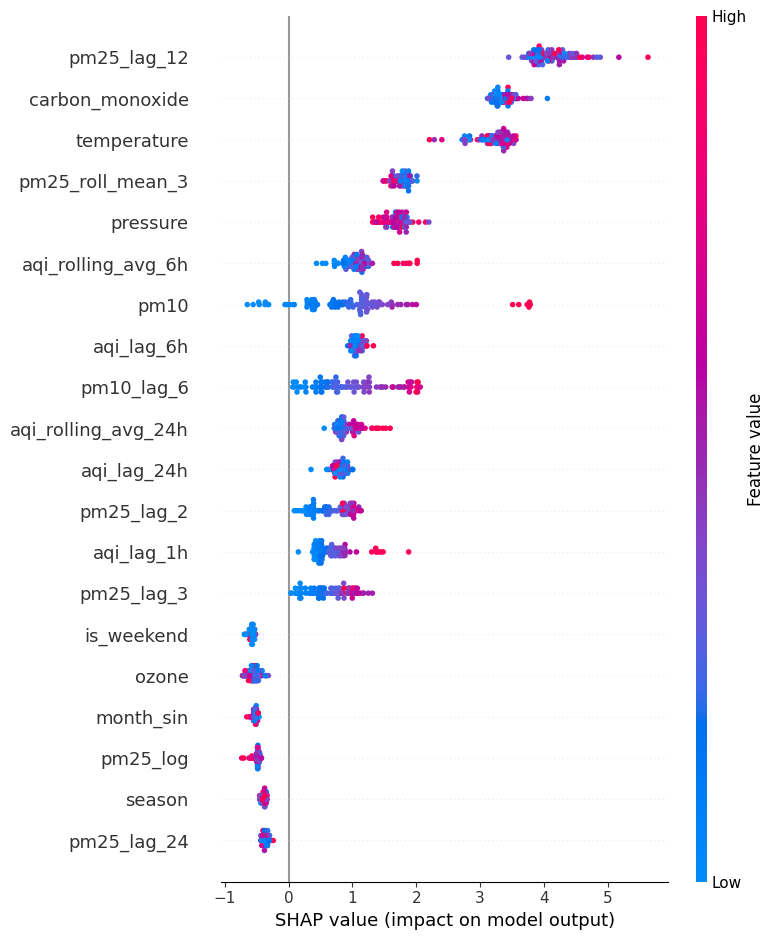


--- Generating SHAP Summary for 48h ---


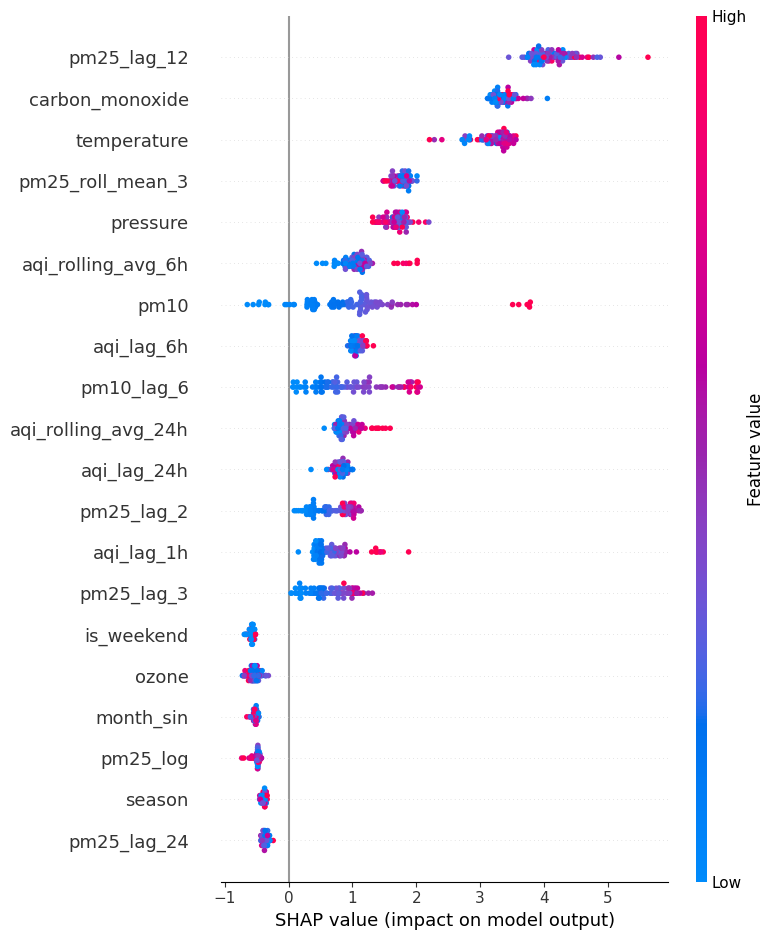


--- Generating SHAP Summary for 72h ---


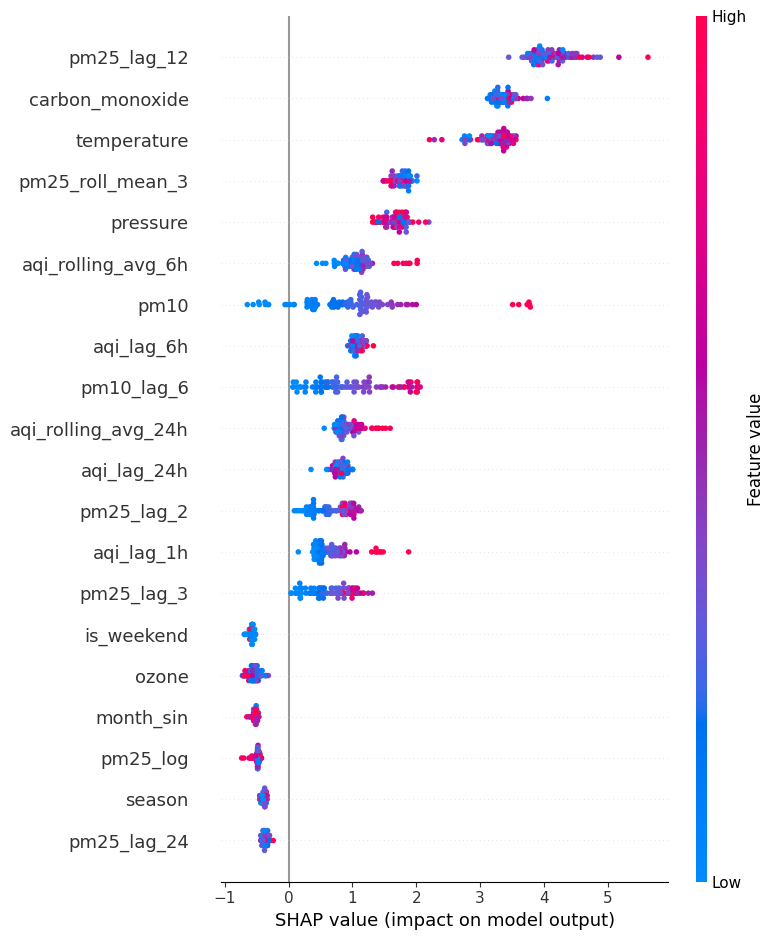

In [ ]:
# 1. Update the features list to remove any columns that aren't in X_numeric
# This keeps only the features that actually exist in your numeric data
features_clean = [f for f in features if f in X_numeric.columns]

# 2. Now filter using the cleaned list
X_numeric = X_numeric[features_clean]

# 3. Check that everything matches
print(f"Features now match X_numeric: {X_numeric.shape}")

# 4. Now run the SHAP analysis
background_data = X_numeric.sample(100, random_state=42)

for horizon, model in champions.items():
    print(f"\n--- Generating SHAP Summary for {horizon} ---")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(background_data)
    shap.summary_plot(shap_values, background_data)